# 05 — M/G/c Extension and Additional Sensitivity Analysis

**Paper:** XAI-Assisted Review and HITL Bottleneck Mitigation: A Queueing Theory Approach  
**Purpose:** Additional experiments required for JORS submission

---

## Notebook structure

| Section | Contents |
|---------|----------|
| 1. M/G/c Analysis | Erlang-C KLB approximation for c = 1, 2, 3 reviewers |
| 2. p Sensitivity | Critical-α curves for p = 0.50, 0.70, 0.90 |
| 3. α_large Sensitivity | Robustness check: α/2, α/3, α/4 assumptions |
| 4. Warm-up Check | SimPy cumulative mean Wq convergence (S1) |
| 5. Output Manifest | All saved figures and tables |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import simpy
from pathlib import Path
from scipy.optimize import brentq
from scipy import stats
from math import factorial

# ── Output directories
FIG_DIR   = Path("figures")
TAB_DIR   = Path("tables")
PAPER_DIR = Path("paper_figures")
for d in [FIG_DIR, TAB_DIR, PAPER_DIR]:
    d.mkdir(exist_ok=True)

# ── Publication style
sns.set_theme(style="white")
plt.rcParams.update({
    "font.family":       "serif",
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    12,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.linewidth":    0.8,
    "grid.linewidth":    0.4,
    "grid.alpha":        0.5,
    "lines.linewidth":   2.0,
})

DPI    = 600
COLORS = {"S1": "#2166ac", "S2": "#f4a582", "S3": "#d6604d"}
LABELS = {"S1": "S1 (No XAI)", "S2": "S2 (Partial XAI)", "S3": "S3 (Full XAI)"}
print("Environment ready.")

Environment ready.


In [2]:
# ── Shared parameters
P_SMALL   = 0.70
S_SMALL_0 = 72.0
S_LARGE_0 =  5.0

SCENARIOS = {
    "S1": {"s_small": 72.0, "s_large": 5.0},
    "S2": {"s_small": 24.0, "s_large": 3.0},
    "S3": {"s_small":  8.0, "s_large": 1.5},
}

def moments(s_small, s_large, p=P_SMALL):
    ES  = p * s_small + (1 - p) * s_large
    ES2 = p * s_small**2 + (1 - p) * s_large**2
    mu  = 1.0 / ES
    return ES, ES2, mu

def pk_wq(lam, ES, ES2):
    rho = lam * ES
    if np.isscalar(lam):
        return np.inf if rho >= 1 else (lam * ES2) / (2 * (1 - rho))
    return np.where(rho < 1, (lam * ES2) / (2 * (1 - rho)), np.inf)

def apply_xai(alpha, ratio=3):
    s_small = S_SMALL_0 / (1 + alpha)
    s_large = S_LARGE_0 / (1 + alpha / ratio)
    return s_small, s_large

def throughput_weekly(mu, h=8, d=5):
    return mu * h * d

MOM = {k: moments(**v) for k, v in SCENARIOS.items()}
mu0 = MOM["S1"][2]

print("Parameters ready.")
print(f"  Baseline mu0 = {mu0:.5f} jobs/h")
print(f"  Baseline weekly throughput = {throughput_weekly(mu0):.2f} jobs/wk")

Parameters ready.
  Baseline mu0 = 0.01927 jobs/h
  Baseline weekly throughput = 0.77 jobs/wk


## 
SECTION 1: M/G/c — Erlang-C based approximation
=============================================================================
M/G/c exact solution does not exist in closed form.
We use the Krämer-Langenbach-Belz (KLB) approximation, which is the
standard approach for M/G/c in the OR literature:

  Wq(M/G/c) ≈ Wq(M/M/c) * [1 + CV²_S] / 2

where CV_S = sigma[S] / E[S] is the coefficient of variation of service time,
and Wq(M/M/c) is computed from the Erlang-C formula.

Reference: Whitt (1993), "Approximations for the GI/G/m queue",
           Production and Operations Management, 2(2), 114-161.
This approximation is tight for the two-point mixture distribution used here.


In [3]:
def erlang_c(c, rho_total):
    """
    Erlang-C probability: P(waiting) for M/M/c queue.
    c     : number of servers
    rho_total : total traffic intensity = lambda / mu (= lambda * E[S])
    rho_per_server = rho_total / c must be < 1 for stability.
    """
    r = rho_total           # lambda / mu  (= lambda * E[S])
    a = r                   # offered load
    rho = a / c             # utilization per server

    if rho >= 1:
        return np.inf       # unstable

    # Numerator: a^c / c! * 1/(1-rho)
    from math import factorial
    num = (a ** c) / factorial(c) * (1 / (1 - rho))

    # Denominator: sum_{k=0}^{c-1} a^k/k!  +  num
    denom = sum((a ** k) / factorial(k) for k in range(c)) + num

    return num / denom      # P(waiting)

def mgc_wq_klb(lam, ES, ES2, c):
    """
    KLB approximation for M/G/c mean waiting time in queue.
    Reduces to exact M/G/1 P-K formula when c=1.
    """
    rho_total = lam * ES               # total traffic intensity
    rho_per   = rho_total / c          # per-server utilization
    mu        = 1.0 / ES              # individual server rate

    if rho_per >= 1:
        return np.inf

    # M/M/c waiting time (Erlang-C)
    C = erlang_c(c, rho_total)
    if np.isinf(C):
        return np.inf
    Wq_mmc = C / (c * mu * (1 - rho_per))

    # Coefficient of variation squared
    VarS = ES2 - ES**2
    CV2  = VarS / (ES**2)

    # KLB correction
    Wq_mgc = Wq_mmc * (1 + CV2) / 2

    return Wq_mgc

### Table A1: M/G/c scenario comparison at rho_per = 0.60

In [4]:
print("\n=== Table A1: M/G/c Scenario Comparison (rho_per = 0.60) ===")

rows_mgc = []
for k in ["S1", "S2", "S3"]:
    ES, ES2, mu = MOM[k]
    for c in [1, 2, 3]:
        # Set lambda so that rho_per_server = 0.60
        lam = 0.60 * c * mu
        rho_total = lam * ES
        rho_per   = rho_total / c
        Wq = mgc_wq_klb(lam, ES, ES2, c)
        rows_mgc.append({
            "Scenario":          LABELS[k],
            "Servers c":         c,
            "lambda (jobs/h)":   round(lam, 5),
            "rho_total":         round(rho_total, 3),
            "rho_per_server":    round(rho_per, 3),
            "Wq (h)":            round(Wq, 3) if not np.isinf(Wq) else "unstable",
            "Throughput (j/wk)": round(throughput_weekly(c * mu), 2),
        })

df_mgc = pd.DataFrame(rows_mgc)
print(df_mgc.to_string(index=False))
df_mgc.to_csv(TAB_DIR / "tableA1_mgc_comparison.csv", index=False)
print(f"Saved -> {TAB_DIR}/tableA1_mgc_comparison.csv")


=== Table A1: M/G/c Scenario Comparison (rho_per = 0.60) ===
        Scenario  Servers c  lambda (jobs/h)  rho_total  rho_per_server  Wq (h)  Throughput (j/wk)
     S1 (No XAI)          1          0.01156        0.6             0.6  52.548               0.77
     S1 (No XAI)          2          0.02312        1.2             0.6  19.705               1.54
     S1 (No XAI)          3          0.03468        1.8             0.6  10.356               2.31
S2 (Partial XAI)          1          0.03390        0.6             0.6  17.199               2.26
S2 (Partial XAI)          2          0.06780        1.2             0.6   6.450               4.52
S2 (Partial XAI)          3          0.10169        1.8             0.6   3.390               6.78
   S3 (Full XAI)          1          0.09917        0.6             0.6   5.637               6.61
   S3 (Full XAI)          2          0.19835        1.2             0.6   2.114              13.22
   S3 (Full XAI)          3          0.29752   

### Table A2: Stability threshold expansion with c servers

In [5]:
print("\n=== Table A2: Stability Threshold by Scenario and c ===")

rows_stab = []
for k in ["S1", "S2", "S3"]:
    ES, ES2, mu = MOM[k]
    for c in [1, 2, 3]:
        lambda_star = c * mu   # stability threshold for c servers
        rows_stab.append({
            "Scenario":                  LABELS[k],
            "Servers c":                 c,
            "lambda* (jobs/h)":          round(lambda_star, 5),
            "lambda* (jobs/day, 8h)":    round(lambda_star * 8, 3),
            "Throughput (jobs/wk)":      round(throughput_weekly(c * mu), 2),
            "Ratio vs S1 c=1":           round(lambda_star / mu0, 2),
        })

df_stab = pd.DataFrame(rows_stab)
print(df_stab.to_string(index=False))
df_stab.to_csv(TAB_DIR / "tableA2_mgc_stability.csv", index=False)
print(f"Saved -> {TAB_DIR}/tableA2_mgc_stability.csv")


=== Table A2: Stability Threshold by Scenario and c ===
        Scenario  Servers c  lambda* (jobs/h)  lambda* (jobs/day, 8h)  Throughput (jobs/wk)  Ratio vs S1 c=1
     S1 (No XAI)          1           0.01927                   0.154                  0.77             1.00
     S1 (No XAI)          2           0.03854                   0.308                  1.54             2.00
     S1 (No XAI)          3           0.05780                   0.462                  2.31             3.00
S2 (Partial XAI)          1           0.05650                   0.452                  2.26             2.93
S2 (Partial XAI)          2           0.11299                   0.904                  4.52             5.86
S2 (Partial XAI)          3           0.16949                   1.356                  6.78             8.80
   S3 (Full XAI)          1           0.16529                   1.322                  6.61             8.58
   S3 (Full XAI)          2           0.33058                   2.645  

### Figure A1: Wq vs lambda for M/G/c (c=1,2,3), scenario S1
Shows how adding reviewers expands the stable operating region

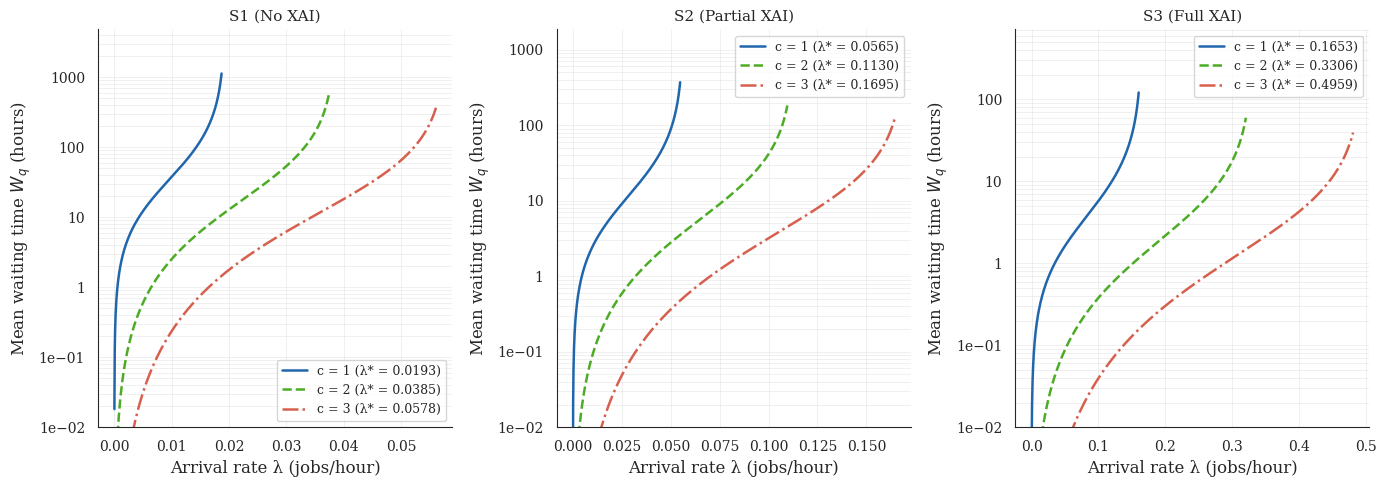

Saved -> paper_figures/paper_figA1_mgc_Wq.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
c_colors  = ["#2166ac", "#4dac26", "#d6604d"]
c_styles  = ["-", "--", "-."]

for ax, (k, label) in zip(axes, LABELS.items()):
    ES, ES2, mu = MOM[k]
    ax.set_title(label, fontsize=11)

    for c, color, ls in zip([1, 2, 3], c_colors, c_styles):
        lam_max = c * mu * 0.97
        lam_arr = np.linspace(1e-5, lam_max, 600)
        Wq_arr  = np.array([mgc_wq_klb(l, ES, ES2, c) for l in lam_arr])
        finite  = np.isfinite(Wq_arr) & (Wq_arr > 0)
        ax.plot(lam_arr[finite], Wq_arr[finite],
                color=color, linestyle=ls, linewidth=1.8,
                label=f"c = {c} (λ* = {c*mu:.4f})")

    ax.set_xlabel("Arrival rate λ (jobs/hour)")
    ax.set_ylabel("Mean waiting time $W_q$ (hours)")
    ax.set_yscale("log")
    # ScalarFormatter 대신 LogFormatter 사용
    ax.yaxis.set_major_formatter(mticker.LogFormatter(labelOnlyBase=False))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_ylim(bottom=1e-2)   # 음수 영역 차단
    ax.legend(fontsize=9)
    ax.grid(True, which="both")

plt.tight_layout()
plt.savefig(PAPER_DIR / "paper_figA1_mgc_Wq.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved -> {PAPER_DIR}/paper_figA1_mgc_Wq.png")

### Figure A2: Capacity ratio vs c across scenarios
Bar chart: lambda* / lambda*_{S1,c=1} for each (scenario, c) combination

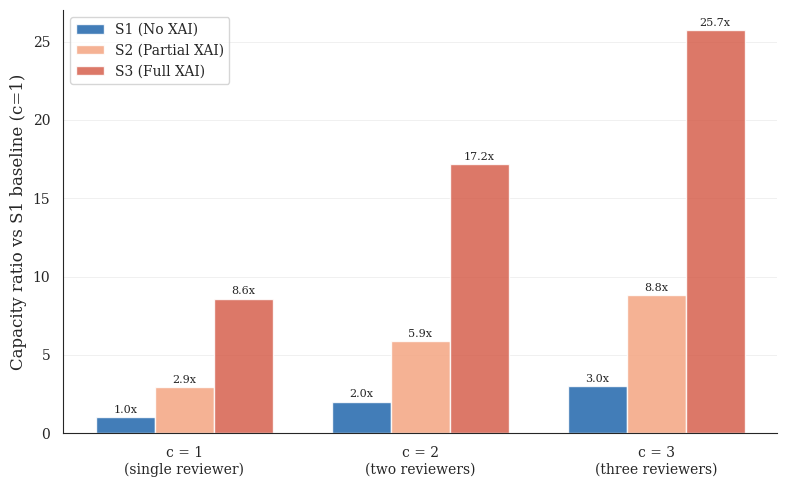

Saved -> paper_figures/paper_figA2_mgc_capacity.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

x       = np.arange(3)           # c = 1, 2, 3
width   = 0.25
offsets = [-width, 0, width]

for offset, (k, label), color in zip(offsets, LABELS.items(), COLORS.values()):
    ratios = [c * MOM[k][2] / mu0 for c in [1, 2, 3]]
    bars   = ax.bar(x + offset, ratios, width=width,
                    label=label, color=color, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, ratios):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.15,
                f"{val:.1f}x",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(["c = 1\n(single reviewer)", "c = 2\n(two reviewers)", "c = 3\n(three reviewers)"])
ax.set_ylabel("Capacity ratio vs S1 baseline (c=1)")
ax.legend(loc="upper left")
ax.grid(axis="y")

plt.tight_layout()
plt.savefig(PAPER_DIR / "paper_figA2_mgc_capacity.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved -> {PAPER_DIR}/paper_figA2_mgc_capacity.png")

## 
SECTION 2: Critical-alpha curves for p = 0.5, 0.7, 0.9
=============================================================================
Answers reviewer question: how sensitive is the critical-alpha curve
to the assumed portfolio composition?


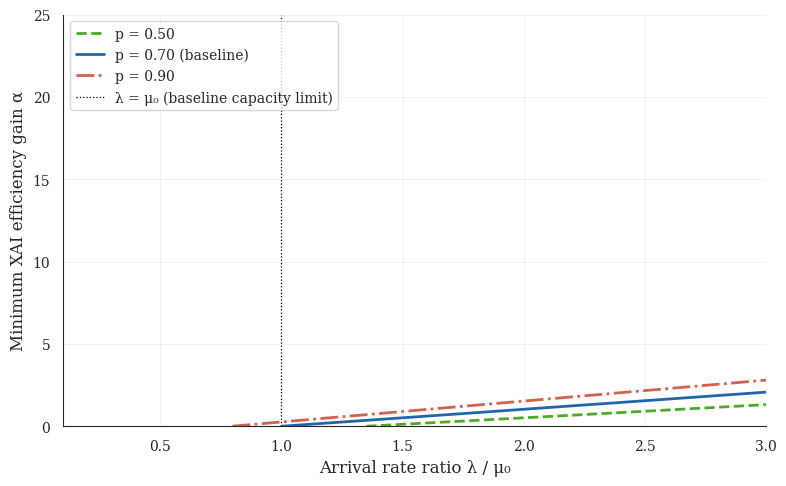

Saved -> paper_figures/paper_figA3_critical_alpha_p_sensitivity.png


In [8]:
def alpha_critical_p(lam, p_small):
    """Minimum alpha for stability given arrival rate and portfolio composition."""
    ES0, _, _ = moments(S_SMALL_0, S_LARGE_0, p_small)
    if lam * ES0 < 1:
        return 0.0
    def f(a):
        ss, sl   = apply_xai(a)
        ES, _, _ = moments(ss, sl, p_small)
        return lam * ES - 1.0
    try:
        return brentq(f, 0, 500)
    except ValueError:
        return np.nan

p_values    = [0.5, 0.7, 0.9]
p_colors    = ["#4dac26", "#2166ac", "#d6604d"]
p_styles    = ["--", "-", "-."]
p_labels    = ["p = 0.50", "p = 0.70 (baseline)", "p = 0.90"]

lam_sweep = np.linspace(0.1 * mu0, 3.0 * mu0, 400)

fig, ax = plt.subplots(figsize=(8, 5))

for p, color, ls, label in zip(p_values, p_colors, p_styles, p_labels):
    alpha_crit = np.array([alpha_critical_p(l, p) for l in lam_sweep])
    mask       = alpha_crit > 0
    if mask.any():
        ax.plot(lam_sweep[mask] / mu0, alpha_crit[mask],
                color=color, linestyle=ls, linewidth=2.0, label=label)

ax.axvline(1.0, color="black", linewidth=0.9, linestyle=":",
           label="λ = μ₀ (baseline capacity limit)")
ax.set_xlabel("Arrival rate ratio λ / μ₀")
ax.set_ylabel("Minimum XAI efficiency gain α")
ax.set_xlim(0.1, 3.0)
ax.set_ylim(0, 25)
ax.legend(loc="upper left")
ax.grid(True)

plt.tight_layout()
plt.savefig(PAPER_DIR / "paper_figA3_critical_alpha_p_sensitivity.png",
            dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved -> {PAPER_DIR}/paper_figA3_critical_alpha_p_sensitivity.png")

### Table A3: Critical alpha at key lambda multiples for p = 0.5, 0.7, 0.9

In [9]:
print("\n=== Table A3: Critical Alpha by Portfolio Composition ===")

key_mults = [1.2, 1.5, 2.0, 3.0]
rows_pa   = []
for mult in key_mults:
    lam = mult * mu0
    row = {"lambda / mu0": mult, "lambda (jobs/h)": round(lam, 5)}
    for p in p_values:
        a = alpha_critical_p(lam, p)
        row[f"alpha_crit (p={p})"] = round(a, 3) if not np.isnan(a) else "N/A"
    rows_pa.append(row)

df_pa = pd.DataFrame(rows_pa)
print(df_pa.to_string(index=False))
df_pa.to_csv(TAB_DIR / "tableA3_critical_alpha_p_sensitivity.csv", index=False)
print(f"Saved -> {TAB_DIR}/tableA3_critical_alpha_p_sensitivity.csv")


=== Table A3: Critical Alpha by Portfolio Composition ===
 lambda / mu0  lambda (jobs/h)  alpha_crit (p=0.5)  alpha_crit (p=0.7)  alpha_crit (p=0.9)
          1.2          0.02312               0.000               0.204               0.513
          1.5          0.02890               0.118               0.513               0.894
          2.0          0.03854               0.512               1.030               1.529
          3.0          0.05780               1.313               2.071               2.802
Saved -> tables/tableA3_critical_alpha_p_sensitivity.csv


## 
SECTION 3: alpha_large ratio sensitivity (alpha/2, alpha/3, alpha/4)
=============================================================================
Baseline: alpha_large = alpha / 3
Tests: alpha / 2 (stronger mid-size effect), alpha / 4 (weaker mid-size effect)
Shows robustness of the critical-alpha curve to this assumption.


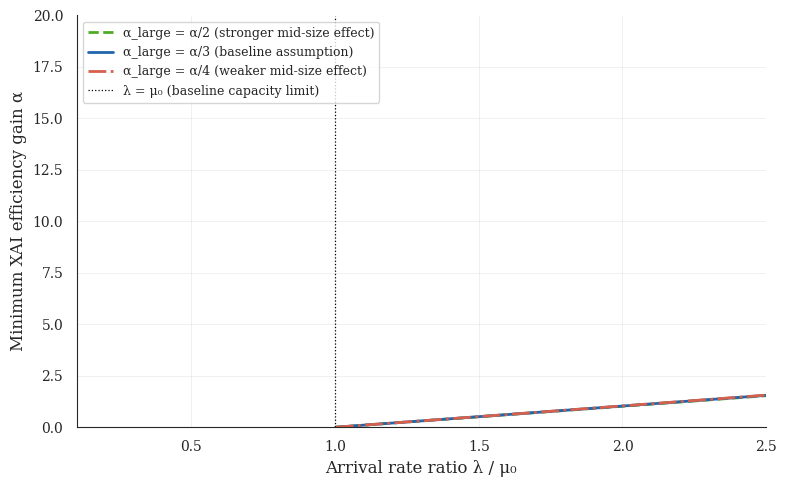

Saved -> paper_figures/paper_figA4_alpha_ratio_sensitivity.png


In [10]:
ratio_values = [2, 3, 4]
ratio_colors = ["#4dac26", "#2166ac", "#d6604d"]
ratio_styles = ["--", "-", "-."]
ratio_labels = [
    "α_large = α/2 (stronger mid-size effect)",
    "α_large = α/3 (baseline assumption)",
    "α_large = α/4 (weaker mid-size effect)",
]

def alpha_critical_ratio(lam, ratio, p_small=P_SMALL):
    """Minimum alpha for stability given alpha_large = alpha / ratio."""
    ES0, _, _ = moments(S_SMALL_0, S_LARGE_0, p_small)
    if lam * ES0 < 1:
        return 0.0
    def f(a):
        ss, sl   = apply_xai(a, ratio=ratio)
        ES, _, _ = moments(ss, sl, p_small)
        return lam * ES - 1.0
    try:
        return brentq(f, 0, 500)
    except ValueError:
        return np.nan

lam_sweep2 = np.linspace(0.1 * mu0, 2.5 * mu0, 400)

fig, ax = plt.subplots(figsize=(8, 5))

for ratio, color, ls, label in zip(ratio_values, ratio_colors, ratio_styles, ratio_labels):
    alpha_crit = np.array([alpha_critical_ratio(l, ratio) for l in lam_sweep2])
    mask       = alpha_crit > 0
    if mask.any():
        ax.plot(lam_sweep2[mask] / mu0, alpha_crit[mask],
                color=color, linestyle=ls, linewidth=2.0, label=label)

ax.axvline(1.0, color="black", linewidth=0.9, linestyle=":",
           label="λ = μ₀ (baseline capacity limit)")
ax.set_xlabel("Arrival rate ratio λ / μ₀")
ax.set_ylabel("Minimum XAI efficiency gain α")
ax.set_xlim(0.1, 2.5)
ax.set_ylim(0, 20)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig(PAPER_DIR / "paper_figA4_alpha_ratio_sensitivity.png",
            dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved -> {PAPER_DIR}/paper_figA4_alpha_ratio_sensitivity.png")

### Table A4: Critical alpha by ratio at key lambda multiples

In [11]:
print("\n=== Table A4: Critical Alpha by alpha_large Ratio ===")

rows_ra = []
for mult in [1.2, 1.5, 2.0]:
    lam = mult * mu0
    row = {"lambda / mu0": mult}
    for ratio in ratio_values:
        a = alpha_critical_ratio(lam, ratio)
        row[f"alpha_crit (ratio={ratio})"] = round(a, 3) if not np.isnan(a) else "N/A"
    rows_ra.append(row)

df_ra = pd.DataFrame(rows_ra)
print(df_ra.to_string(index=False))
df_ra.to_csv(TAB_DIR / "tableA4_alpha_ratio_sensitivity.csv", index=False)
print(f"Saved -> {TAB_DIR}/tableA4_alpha_ratio_sensitivity.csv")


=== Table A4: Critical Alpha by alpha_large Ratio ===
 lambda / mu0  alpha_crit (ratio=2)  alpha_crit (ratio=3)  alpha_crit (ratio=4)
          1.2                 0.203                 0.204                 0.205
          1.5                 0.509                 0.513                 0.515
          2.0                 1.020                 1.030                 1.036
Saved -> tables/tableA4_alpha_ratio_sensitivity.csv


## 
SECTION 4: Warm-up adequacy check (SimPy)
=============================================================================
Shows that the 50-job warm-up is sufficient for the cumulative mean Wq
to stabilise before the measurement phase begins.
Run only for S1 (worst case: highest Wq variance).



=== Section 4: Warm-up Adequacy Check (S1, single replication) ===


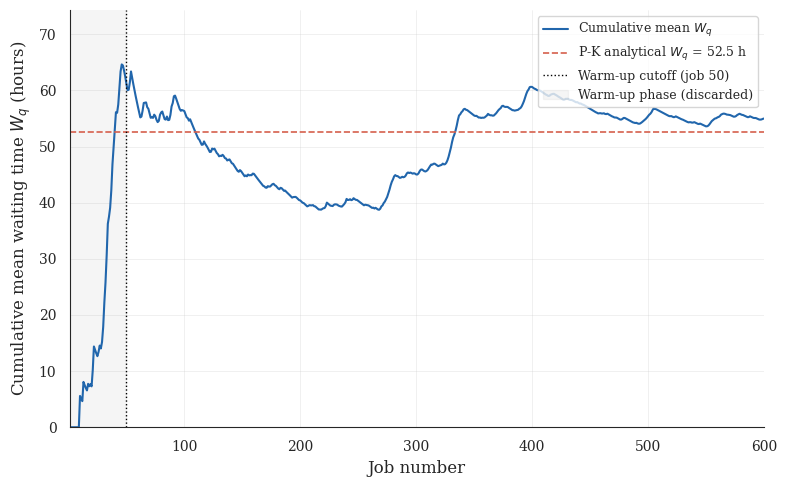

Saved -> paper_figures/paper_figA5_warmup_adequacy.png
  P-K reference Wq = 52.55 h
  Cumulative mean after warm-up (job 51 onward): 51.11 h


In [12]:
print("\n=== Section 4: Warm-up Adequacy Check (S1, single replication) ===")

P_SMALL_SIM = 0.70
N_TOTAL     = 600       # total jobs including warm-up
WARM_UP     = 50
SEED_WU     = 9999
LAM_WU      = 0.60 * mu0

def run_warmup_check(s_small, s_large, lam, n_total, seed):
    """
    Run single SimPy replication tracking cumulative mean Wq per job.
    Returns array of cumulative means (length = n_total).
    """
    rng    = np.random.default_rng(seed)
    env    = simpy.Environment()
    server = simpy.Resource(env, capacity=1)
    wq_all = []

    def job(env):
        arrival = env.now
        with server.request() as req:
            yield req
            wait = env.now - arrival
            svc  = s_small if rng.random() < P_SMALL_SIM else s_large
            yield env.timeout(svc)
            wq_all.append(wait)

    def arrivals(env):
        for _ in range(n_total):
            iat = rng.exponential(1.0 / lam)
            yield env.timeout(iat)
            env.process(job(env))

    env.process(arrivals(env))
    env.run()

    cumulative_mean = np.array([
        np.mean(wq_all[:i+1]) for i in range(len(wq_all))
    ])
    return cumulative_mean

cum_mean = run_warmup_check(
    s_small  = SCENARIOS["S1"]["s_small"],
    s_large  = SCENARIOS["S1"]["s_large"],
    lam      = LAM_WU,
    n_total  = N_TOTAL,
    seed     = SEED_WU,
)

# P-K analytical reference for S1 at rho=0.60
ES1, ES21, _ = MOM["S1"]
wq_analytical = pk_wq(LAM_WU, ES1, ES21)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(np.arange(1, len(cum_mean) + 1), cum_mean,
        color="#2166ac", linewidth=1.5, label="Cumulative mean $W_q$")
ax.axhline(wq_analytical, color="#d6604d", linewidth=1.2, linestyle="--",
           label=f"P-K analytical $W_q$ = {wq_analytical:.1f} h")
ax.axvline(WARM_UP, color="black", linewidth=1.0, linestyle=":",
           label=f"Warm-up cutoff (job {WARM_UP})")
ax.fill_betweenx([0, cum_mean.max() * 1.2], 0, WARM_UP,
                 alpha=0.08, color="gray", label="Warm-up phase (discarded)")

ax.set_xlabel("Job number")
ax.set_ylabel("Cumulative mean waiting time $W_q$ (hours)")
ax.set_xlim(1, N_TOTAL)
ax.set_ylim(0, cum_mean.max() * 1.15)
ax.legend(fontsize=9, loc="upper right")
ax.grid(True)

plt.tight_layout()
plt.savefig(PAPER_DIR / "paper_figA5_warmup_adequacy.png",
            dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved -> {PAPER_DIR}/paper_figA5_warmup_adequacy.png")
print(f"  P-K reference Wq = {wq_analytical:.2f} h")
print(f"  Cumulative mean after warm-up (job 51 onward): "
      f"{np.mean(cum_mean[WARM_UP:]):.2f} h")

## 
SECTION 5: Output manifest
=============================================================================

In [13]:
print("\n=== Output manifest ===")
print("\n[paper_figures/]")
for f in sorted(PAPER_DIR.iterdir()):
    if f.suffix in [".png", ".csv"]:
        print(f"  {f.name:<50} {f.stat().st_size/1024:>7.1f} KB")

print("\n[tables/]")
for f in sorted(TAB_DIR.iterdir()):
    if "A" in f.stem:
        print(f"  {f.name:<50} {f.stat().st_size/1024:>7.1f} KB")

print("\nDone. All JORS additional analyses complete.")


=== Output manifest ===

[paper_figures/]
  paper_fig1_pipeline.png                              366.4 KB
  paper_fig2_rho_lambda.png                            335.6 KB
  paper_fig3_Wq_lambda.png                             306.9 KB
  paper_fig4_throughput.png                            164.1 KB
  paper_fig5_validation.png                            225.8 KB
  paper_fig6_critical_alpha.png                        291.8 KB
  paper_fig7_heatmap.png                               345.1 KB
  paper_figA1_mgc_Wq.png                               634.0 KB
  paper_figA2_mgc_capacity.png                         243.6 KB
  paper_figA3_critical_alpha_p_sensitivity.png         254.3 KB
  paper_figA4_alpha_ratio_sensitivity.png              302.6 KB
  paper_figA5_warmup_adequacy.png                      369.6 KB
  paper_table1_scenarios.csv                             0.3 KB
  paper_table2_validation.csv                            0.3 KB
  paper_table3_critical_alpha.csv                        0.3 